In [1]:
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModel
from transformers import BertTokenizerFast
from transformers import BertForSequenceClassification
import re
from torch import cuda
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from torch.utils.data import Dataset
from transformers import TrainingArguments, Trainer

device = 'cuda' if cuda.is_available() else 'cpu'

In [2]:
tokenizer = BertTokenizerFast.from_pretrained("cointegrated/rubert-tiny")
model = BertForSequenceClassification.from_pretrained(
    "cointegrated/rubert-tiny", num_labels=3
)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/341 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/632 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/47.7M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cointegrated/rubert-tiny
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider train

In [3]:
model.to(device)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(29564, 312, padding_idx=0)
      (position_embeddings): Embedding(512, 312)
      (token_type_embeddings): Embedding(2, 312)
      (LayerNorm): LayerNorm((312,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-2): 3 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=312, out_features=312, bias=True)
              (key): Linear(in_features=312, out_features=312, bias=True)
              (value): Linear(in_features=312, out_features=312, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=312, out_features=312, bias=True)
              (LayerNorm): LayerNorm((312,), eps=1e-12, e

In [4]:
model.load_state_dict(torch.load("model_rubert-tiny1.pt"))
model.eval()

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(29564, 312, padding_idx=0)
      (position_embeddings): Embedding(512, 312)
      (token_type_embeddings): Embedding(2, 312)
      (LayerNorm): LayerNorm((312,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-2): 3 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=312, out_features=312, bias=True)
              (key): Linear(in_features=312, out_features=312, bias=True)
              (value): Linear(in_features=312, out_features=312, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=312, out_features=312, bias=True)
              (LayerNorm): LayerNorm((312,), eps=1e-12, e

In [5]:
df = pd.read_excel('test_df.xls')

In [6]:
df

,date,text
0,2026-03-13,ДЕФИЦИТ ЗАЖЁГ ОГОНЬ.\nПАНИКА ПОМОГЛА РАЗГОРЕТЬ...
1,2026-03-13,НАСТОЯЩАЯ ЦЕЛЬ: НЕ ИРАН И НЕ ЯДЕРНАЯ БОМБА \nЯ...
2,2026-03-13,КАК КРИЗИС УБИВАЕТ ПРОИЗВОДСТВО — ВОЛНА ЗА ВОЛ...
3,2026-03-13,"ВОЛНА ПЕРВАЯ — ПРЯМО СЕЙЧАС: металл, химия, тр..."
4,2026-03-13,ВОЛНА ТРЕТЬЯ — ЧЕРЕЗ 8–10 МЕСЯЦЕВ: продовольст...
5,2026-03-13,"КИТАЙ: тактическая победа, стратегическая уязв..."
6,2026-03-13,Утренняя сводка на 13 марта\n\nКалендарь\nВели...
7,2026-03-12,С начала недели нефть марки Brent дорожает на ...
8,2026-03-12,Четверг на валютном рынке снова стал днем нефт...
9,2026-03-12,"Утром фьючерс на индекс S&P 500 падает на 0,48..."


In [7]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem.snowball import SnowballStemmer

nltk.download('stopwords')
nltk.download('punkt_tab')



# Стемминг + стоп-слова
russian_stopwords = set(stopwords.words('russian'))
stemmer = SnowballStemmer("russian")

def preprocess_text(text):
    tokens = word_tokenize(text, language='russian')
    stems = []
    for token in tokens:
        if token.isalpha():
            stem = stemmer.stem(token.lower())
            if stem not in russian_stopwords:
                stems.append(stem)
    return ' '.join(stems)

df['text'] = df['text'].apply(preprocess_text)
df = df[df['text'].str.strip() != '']

print("Пример результата:")
print(df.head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Пример результата:
        date                                               text
0 2026-03-13  дефиц зажег огон паник помогл разгорет энергет...
1 2026-03-13  настоя цел ира ядерн бомб ядерн программ ира у...
2 2026-03-13  кризис убива производств волн волн большинств ...
3 2026-03-13  волн перв прям металл хим транспорт электродуг...
4 2026-03-13  волн трет месяц продовольствен удар эт опасн н...


In [8]:
texts = df["text"].tolist()

In [9]:
def predict(text):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits
    pred = torch.argmax(logits, dim=1).item()

    return pred

In [10]:
df["prediction"] = df["text"].apply(predict)

In [11]:
df['prediction'].value_counts()

,count
prediction,
1,17
0,8
2,2


формула расчета эконометрического индикатора

In [17]:
summ = 27
increase_num = 8
fall_num = 2
stable_num = 17

increase = summ * (increase_num/100)
fall = summ * (fall_num/100)
summ_trends = increase+fall

increase_weight = increase/summ_trends

fall_weight = fall/summ_trends


50 + (increase_num + stable_num*increase_weight)*0.5 - (fall_num+ stable_num*fall_weight)*0.5


58.099999999999994

In [15]:
increase, fall, summ_trends, increase_weight, fall_weight

(2.16, 0.54, 2.7, 0.8, 0.2)

In [ ]:
# df_inf_2 = pd.read_excel(end_path, skiprows=5) # рабочий датасет для расчетов

#     df_inf_1 = pd.read_excel(i+file_links[0], skiprows=5) # датасет с количеством предприятий
#     summ_org = df_inf_1[4] # сумма предприятий
#     middle_org = df_inf_1[5] # средние предприятия
#     big_org = df_inf_1[6] # крупные предприятия


#     increase = summ_org*(df_inf_2[1]/100) # коэф. повышения
#     fall = summ_org*(df_inf_2[3]/100) # коэф. понижения

#     non_changes = summ_org - increase - fall
#     summ_trends = increase+fall

#     increase_weight = increase/summ_trends # вес повышения
#     fall_weight = fall/summ_trends # вес понижения

#     # формула расчета PMI

#     oi = 50 + (df_inf_2[6]+df_inf_2[7]*increase_weight)*0.5 - (df_inf_2[8]+df_inf_2[7]*fall_weight)*0.5
#     print(oi[0])
#     oi_production.append(oi[0])
#     oi_processing.append(oi[6])

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [75]:
df_brent

,Дата,Цена,Откр.,Макс.,Мин.,Объём,Изм. %
9,2026-03-02,77.74,"81,57","82,37","75,75","1,14M","7,26%"
8,2026-03-03,81.40,"79,00","85,12","78,38","1,21M","4,71%"
7,2026-03-04,81.40,"82,00","84,48","80,30","791,43K","0,00%"
6,2026-03-05,85.41,"82,24","86,28","81,50","891,29K","4,93%"
5,2026-03-06,92.69,"83,54","94,64","83,16","1,01M","8,52%"
4,2026-03-09,98.96,"99,75","119,50","83,66","1,22M","6,76%"
3,2026-03-10,87.80,"92,49","95,04","81,16","881,22K","-11,28%"
2,2026-03-11,91.98,"90,40","93,80","86,24","689,37K","4,76%"
1,2026-03-12,100.46,"96,84","101,85","95,20","660,22K","9,22%"
0,2026-03-13,103.14,"101,68","103,95","97,60","453,07K","2,67%"


KeyError: 'Дата'

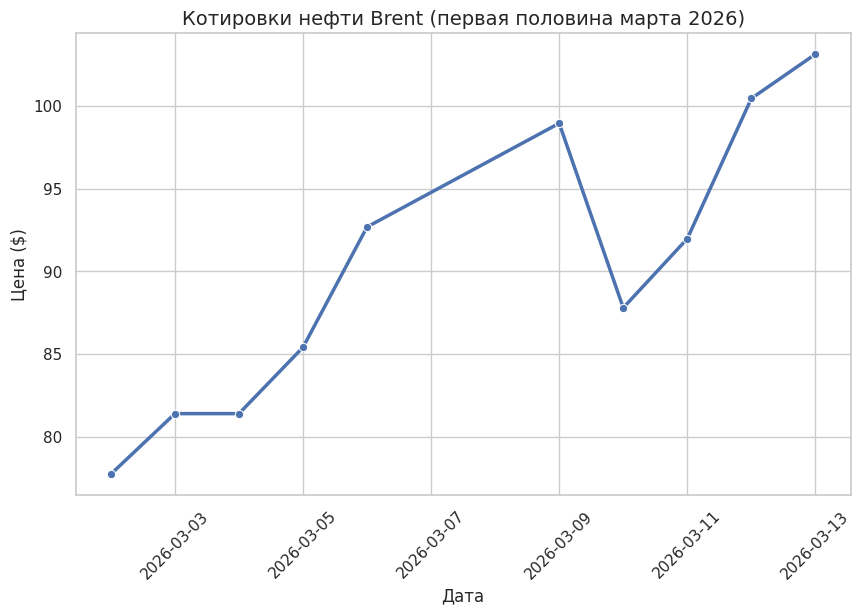

In [77]:
df_brent = pd.read_csv('data_brent_01_15_march.csv')


# Преобразование типов
df_brent["Дата"] = pd.to_datetime(df_brent["Дата"], format="%d.%m.%Y")
df_brent["Цена"] = df_brent["Цена"].str.replace(",", ".").astype(float)

# Сортировка по дате
df_brent = df_brent.sort_values("Дата")

# Стиль графика
sns.set(style="whitegrid")

plt.figure(figsize=(10,6))

sns.lineplot(
    data=df_brent,
    x="Дата",
    y="Цена",
    marker="o",
    linewidth=2.5
)

plt.title("Котировки нефти Brent (первая половина марта 2026)", fontsize=14)
plt.xlabel("Дата")
plt.ylabel("Цена ($)")
plt.xticks(rotation=45)

# Подписи точек
for x, y in zip(df["Дата"], df["Цена"]):
    plt.text(x, y+0.5, f"{y:.2f}", ha='center')

plt.tight_layout()
plt.show()